5350 Thesis in Economics

Andres Cruz 25199 & Klara Holmer 25037 

Code for Grundskola and Gymnasieskola

In [1]:
# Importing Libraries
import numpy as np 
import pandas as pd 
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Step 1 - Importing ExcelFiles and Concatenating DataFrames

# --- Gymnasieskola  Årskurs 1 or Upper Secondary School Year 10 --- 

# Defining the full path to the Excel file in the new folder
pathname = '/Users/andrescruz/Documents/Handelshögskolan/MSc Economic/Semester 4/5350 Thesis in Economics/Processed Data/Gymnasieskola_Data.xlsx'

# Read all sheets at once into a dictionary
sheets = ['English', 'Mathematics', 'Swedish']
gymnasieskola_data = pd.read_excel(pathname, sheet_name=sheets)

# Unpack the dictionary into separate variables if needed
gymnasieskola_data_english = gymnasieskola_data['English']
gymnasieskola_data_mathematics = gymnasieskola_data['Mathematics']
gymnasieskola_data_swedish = gymnasieskola_data['Swedish']

# --- Lower Secondary School Year 9 --- 

# Defining the full path to the Excel file in the new folder
pathname = '/Users/andrescruz/Documents/Handelshögskolan/MSc Economic/Semester 4/5350 Thesis in Economics/Processed Data/Grundskola_Data.xlsx'

# Read all sheets at once into a dictionary
sheets = ['English', 'Mathematics', 'Swedish']
grundskola_data = pd.read_excel(pathname, sheet_name=sheets)

# Unpack the dictionary into separate variables if needed
grundskola_data_english = grundskola_data['English']
grundskola_data_mathematics = grundskola_data['Mathematics']
grundskola_data_swedish_data = grundskola_data['Swedish']

# --- Concatenating --- 

# Engelska
school_data_english = pd.concat([gymnasieskola_data_english, grundskola_data_english], ignore_index=True)

# Matematik
school_data_mathematics = pd.concat([gymnasieskola_data_mathematics, grundskola_data_mathematics], ignore_index=True)

# Svenska
school_data_swedish = pd.concat([gymnasieskola_data_swedish, grundskola_data_swedish_data], ignore_index=True)

# List of DataFrames
dataframes = [school_data_english, school_data_mathematics, school_data_swedish]

In [3]:
# Step 2 -  Adding County ID 

# Defining the full path to the Excel file in the new folder
pathname = '/Users/andrescruz/Documents/Handelshögskolan/MSc Economic/Semester 4/5350 Thesis in Economics/Raw Data/Kommun Data/georef-sweden-kommun.xlsx'

# Read all sheets at once into a dictionary
kommun_data = pd.read_excel(pathname, sheet_name=0)

# List of new names 
new_names = [
    'geo_point',            # Column 1 Geo Point
    'geo_shape',            # Column 2 Geo Shape
    'year',                 # Column 3 Year
    'county_ID',            # Column 4 Län code
    'school_county',        # Column 5 Län name
    'municipality_ID',      # Column 6 Kommun code
    'school_municipality',  # Column 7 Kommun name
    'area_code',            # Column 8 ISO 3166-3 Area code
    'type',                 # Column 9 Type
    ]

# List of new names 
columns_to_drop = [
    'geo_point',            # Column 1 Geo Point
    'geo_shape',            # Column 2 Geo Shape
    'year',                 # Column 3 Year
    'area_code',            # Column 8 ISO 3166-3 Area code
    'type',                 # Column 9 Type
    ]

# Applying the new names 
kommun_data.columns = new_names

# Drop the specified columns
kommun_data.drop(columns=columns_to_drop, axis=1, inplace=True)

# Define the join keys
join_keys = ['school_municipality', 'municipality_ID']

# Apply merging and store the results back in the list
dataframes = [pd.merge(df, kommun_data, on=join_keys, how='left') for df in dataframes]

# Unpacking the list 
school_data_english, school_data_mathematics, school_data_swedish = dataframes

In [4]:
# Step 3 -  Imputing and dropping columns

# List of DataFrames
dataframes = [school_data_english, school_data_mathematics, school_data_swedish]

# Columns to fill via group-wise backward fill
columns_to_bfill = ['school_size', 'total_school_students', 'graduating_students']

# Define bins and labels for school size categorization
bins = [0, 49, 99, 199, 299, 399, 499, 599, 699, 799, 899, np.inf]
labels = ["1-49", "50-99", "100-199", "200-299", "300-399", "400-499", 
          "500-599", "600-699", "700-799", "800-899", "900-"]

# Define a list of columns to drop
columns_to_drop = [
    'total_school_students',
    'graduating_students',
    'total_fulltime_certified_teachers',
    'total_fulltime_teachers',                                           
    'share_fulltime_certified_teachers',                                    
    'total_active_teachers',                                            
    'total_active_certified_teachers',                                    
    ]

# For Loop 
for df in dataframes:
    # Step 1: Group-wise backward fill for specified columns
    df[columns_to_bfill] = df.groupby('school_ID')[columns_to_bfill].bfill()

    # Step 2: Categorize total_school_students into school_size
    df['school_size'] = pd.cut(
        df['total_school_students'].astype(float),  # Ensure numeric type
        bins=bins,
        labels=labels,
        right=True
    )

    # Dropping columns which will not be used
    df.drop(columns=columns_to_drop, axis=1, inplace=True)

In [5]:
# Step 4 -  Creating Variables 

# Preprocess Function
def preprocess_school_data(df, lang_suffix):
    """
    Preprocess a language-specific school dataset, retaining suffixes to allow merging.

    Parameters:
    - df: pandas DataFrame with subject-specific suffixes (e.g., '_sv')
    - lang_suffix: str, the suffix identifying the subject (e.g., 'sv', 'eng', 'ma')

    Returns:
    - Preprocessed DataFrame (language-specific columns retained)
    """

    # Drop language-specific share_students_A_E variable only
    df = df.drop(columns=[f'share_students_A_E_{lang_suffix}'], errors='ignore')

    return df

school_data_swedish = preprocess_school_data(school_data_swedish, 'sv')
school_data_english = preprocess_school_data(school_data_english, 'eng')
school_data_mathematics = preprocess_school_data(school_data_mathematics, 'ma')

In [6]:
# Step 4 -  Full School DataFrame 

# Find the common school_IDs using set intersection
common_ids = set(school_data_english['school_ID']) \
             & set(school_data_swedish['school_ID']) \
             & set(school_data_mathematics['school_ID'])

# Filter each DataFrame to include only the common school_IDs
school_data_english = school_data_english[school_data_english['school_ID'].isin(common_ids)]
school_data_swedish = school_data_swedish[school_data_swedish['school_ID'].isin(common_ids)]
school_data_mathematics = school_data_mathematics[school_data_mathematics['school_ID'].isin(common_ids)]

# Extract relvant columns for matching 
math_F = school_data_mathematics[['school_ID', 'academic_year', 'share_students_F_ma']]
swedish_F = school_data_swedish[['school_ID', 'academic_year', 'share_students_F_sv']]
english_F = school_data_english[['school_ID', 'academic_year', 'share_students_F_eng']]

# Start from a full base dataset (any one of the three is fine)
school_data = school_data_english.drop(columns=['share_students_F_eng'])

# Merge Swedish share_students_F
school_data = school_data.merge(swedish_F, on=['school_ID', 'academic_year'], how='left')

# Merge English share_students_F
school_data = school_data.merge(english_F, on=['school_ID', 'academic_year'], how='left')

# Finally, merge back Mathematics
school_data = school_data.merge(math_F, on=['school_ID', 'academic_year'], how='left')

school_data

,school_ID,school_municipality,municipality_ID,type_of_ownership,academic_year,educational_stage,school_size,graduates_average_grade_points,share_female_students,share_foreign_background,share_postsecondary_parents,share_active_certified_teachers,county_ID,school_county,share_students_F_sv,share_students_F_eng,share_students_F_ma
0,74776778,Alingsås,1489,Kommunal,2014/15,gymnasieskola,100-199,14.7,43.0,19.0,46.0,75.0,14,Västra Götalands län,0.0,2.3,0.0
1,18345915,Alingsås,1489,Kommunal,2014/15,gymnasieskola,200-299,15.2,30.0,16.0,67.0,93.1,14,Västra Götalands län,0.0,0.0,0.0
2,68229719,Alingsås,1489,Kommunal,2014/15,gymnasieskola,100-199,14.8,63.0,14.0,53.0,91.3,14,Västra Götalands län,0.0,0.0,0.0
3,61004230,Alingsås,1489,Kommunal,2014/15,gymnasieskola,50-99,16.5,66.0,NaN,62.0,75.0,14,Västra Götalands län,0.0,0.0,2.3
4,71262305,Arboga,1984,Kommunal,2014/15,gymnasieskola,100-199,15.5,50.0,13.0,68.0,70.4,19,Västmanlands län,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16917,50308658,Överkalix,2513,Kommunal,2020/21,grundskola,100-199,10.8,43.0,28.0,36.0,70.0,25,Norrbottens län,12.5,22.7,26.1
16918,13342436,Överkalix,2513,Enskild,2020/21,grundskola,50-99,NaN,53.0,NaN,40.0,62.5,25,Norrbottens län,NaN,NaN,NaN
16919,46252858,Övertorneå,2518,Enskild,2020/21,grundskola,50-99,NaN,63.0,NaN,52.0,30.0,25,Norrbottens län,NaN,NaN,NaN
16920,90707437,Övertorneå,2518,Kommunal,2020/21,grundskola,50-99,NaN,57.0,21.0,48.0,62.5,25,Norrbottens län,NaN,NaN,NaN


In [7]:
# --- Grouping and Saving Unique School IDs ---

# Group by 'educational_stage' and 'type_of_ownership' and count unique schools
observations_by_group = school_data.groupby(['educational_stage', 'type_of_ownership'])['school_ID'].nunique().reset_index(name='number_of_schools')

# Generate LaTeX table
latex_observations_table = observations_by_group.to_latex(
    index=False,
    caption="Total Number of Unique Schools by Educational Stage and Type of Ownership",
    label="tab:unique_schools_by_group",
    float_format="%.0f"
)

# Save the table
save_folder = '/Users/andrescruz/Documents/Handelshögskolan/MSc Economic/Semester 4/5350 Thesis in Economics/Output/Data Preparation/'
latex_filename_observations = 'unique_schools_by_group_1.text'
full_path_observations = os.path.join(save_folder, latex_filename_observations)

with open(full_path_observations, 'w') as f:
    f.write(latex_observations_table)

print(f"LaTeX table of unique schools saved successfully at: {full_path_observations}")

LaTeX table of unique schools saved successfully at: /Users/andrescruz/Documents/Handelshögskolan/MSc Economic/Semester 4/5350 Thesis in Economics/Output/Data Preparation/unique_schools_by_group_1.text


In [8]:
# Step 4 - Filtering for school_sizes with 1-49 students 

# - Analysis 1 - # 

# Count the number of observations per school size group
school_size_counts = school_data['school_size'].value_counts().sort_index()

# Convert to DataFrame for table formatting
school_size_hist = school_size_counts.reset_index()
school_size_hist.columns = ['School Size Group', 'Number of Observations']

# Generate LaTeX table
latex_hist_table = school_size_hist.to_latex(
    index=False,
    caption="Number of Observations by School Size Group",
    label="tab:obs_by_school_size",
    float_format="%.0f"
)

# Save path
save_folder = '/Users/andrescruz/Documents/Handelshögskolan/MSc Economic/Semester 4/5350 Thesis in Economics/Output/Data Preparation/'
latex_filename_hist = 'obs_by_school_size.text'
full_path_hist = os.path.join(save_folder, latex_filename_hist)

# Save to .tex file
with open(full_path_hist, 'w') as f:
    f.write(latex_hist_table)

print(f"LaTeX histogram table saved successfully at: {full_path_hist}")

# - Analysis 2 - # 
# Define the specific columns of interest; adjust these names as needed
selected_vars = ['share_female_students', 'share_foreign_background',
                 'share_postsecondary_parents', 'share_active_certified_teachers', 
                 'share_students_F_sv', 'share_students_F_eng', 'share_students_F_ma']

# Group by 'school_size_group' and compute the share of missing values
missing_share_by_group = school_data.groupby('school_size')[selected_vars].apply(lambda group: group.isna().mean())

# Generate the LaTeX table
latex_table = missing_share_by_group.to_latex(
    index=True,
    caption="Share of Missing Values by School Size Group",
    label="tab:missing_share_by_school_size",
    na_rep="0%",
    float_format="%.2f"  # This formats floats to two decimal places
)

# Define the path where you want to save the LaTeX file
save_folder = '/Users/andrescruz/Documents/Handelshögskolan/MSc Economic/Semester 4/5350 Thesis in Economics/Output/Data Preparation/'
latex_filename = 'missing_share_by_school_size.text'

# Full path
full_path = os.path.join(save_folder, latex_filename)

# Save the LaTeX table to a .tex file
with open(full_path, 'w') as f:
    f.write(latex_table)

print(f"LaTeX table saved successfully at: {full_path}")

# ----- Filtering for school_sizes with 1-49 students ----- #
school_data = school_data[school_data['school_size'] != '1-49']


LaTeX histogram table saved successfully at: /Users/andrescruz/Documents/Handelshögskolan/MSc Economic/Semester 4/5350 Thesis in Economics/Output/Data Preparation/obs_by_school_size.text
LaTeX table saved successfully at: /Users/andrescruz/Documents/Handelshögskolan/MSc Economic/Semester 4/5350 Thesis in Economics/Output/Data Preparation/missing_share_by_school_size.text


/var/folders/dk/hpy2mtkd7sq6_2c3125100b80000gn/T/ipykernel_10274/378969396.py:38: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  missing_share_by_group = school_data.groupby('school_size')[selected_vars].apply(lambda group: group.isna().mean())


In [9]:
# --- Grouping and Saving Unique School IDs ---

# Group by 'educational_stage' and 'type_of_ownership' and count unique schools
observations_by_group = school_data.groupby(['educational_stage', 'type_of_ownership'])['school_ID'].nunique().reset_index(name='number_of_schools')

# Generate LaTeX table
latex_observations_table = observations_by_group.to_latex(
    index=False,
    caption="Total Number of Unique Schools by Educational Stage and Type of Ownership",
    label="tab:unique_schools_by_group",
    float_format="%.0f"
)

# Save the table
save_folder = '/Users/andrescruz/Documents/Handelshögskolan/MSc Economic/Semester 4/5350 Thesis in Economics/Output/Data Preparation/'
latex_filename_observations = 'unique_schools_by_group_2.text'
full_path_observations = os.path.join(save_folder, latex_filename_observations)

with open(full_path_observations, 'w') as f:
    f.write(latex_observations_table)

print(f"LaTeX table of unique schools saved successfully at: {full_path_observations}")

LaTeX table of unique schools saved successfully at: /Users/andrescruz/Documents/Handelshögskolan/MSc Economic/Semester 4/5350 Thesis in Economics/Output/Data Preparation/unique_schools_by_group_2.text


In [10]:
# Step 5 - Remove missing values

# List of columns to check for missing values
columns_to_check = [
    'graduates_average_grade_points',
    'share_active_certified_teachers',
    'share_postsecondary_parents',
    'share_foreign_background',
    'share_female_students', 
    'share_students_F_sv', 
    'share_students_F_eng',
    'share_students_F_ma']

# Drop rows where any of the specified columns have missing values
school_data = school_data.dropna(subset=columns_to_check)

In [11]:
# --- Grouping and Saving Unique School IDs ---

# Group by 'educational_stage' and 'type_of_ownership' and count unique schools
observations_by_group = school_data.groupby(['educational_stage', 'type_of_ownership'])['school_ID'].nunique().reset_index(name='number_of_schools')

# Generate LaTeX table
latex_observations_table = observations_by_group.to_latex(
    index=False,
    caption="Total Number of Unique Schools by Educational Stage and Type of Ownership",
    label="tab:unique_schools_by_group",
    float_format="%.0f"
)

# Save the table
save_folder = '/Users/andrescruz/Documents/Handelshögskolan/MSc Economic/Semester 4/5350 Thesis in Economics/Output/Data Preparation/'
latex_filename_observations = 'unique_schools_by_group_3.text'
full_path_observations = os.path.join(save_folder, latex_filename_observations)

with open(full_path_observations, 'w') as f:
    f.write(latex_observations_table)

print(f"LaTeX table of unique schools saved successfully at: {full_path_observations}")

LaTeX table of unique schools saved successfully at: /Users/andrescruz/Documents/Handelshögskolan/MSc Economic/Semester 4/5350 Thesis in Economics/Output/Data Preparation/unique_schools_by_group_3.text


In [12]:
# Step 6 - Balancing my panel data

# Determine the total number of distinct academic years
n_periods = school_data['academic_year'].nunique()

# Balance the panel: keep only schools present in all academic years
school_data = school_data.groupby('school_ID').filter(lambda group: group['academic_year'].nunique() == n_periods)

In [13]:
# --- Grouping and Saving Unique School IDs ---

# Group by 'educational_stage' and 'type_of_ownership' and count unique schools
observations_by_group = school_data.groupby(['educational_stage', 'type_of_ownership'])['school_ID'].nunique().reset_index(name='number_of_schools')

# Generate LaTeX table
latex_observations_table = observations_by_group.to_latex(
    index=False,
    caption="Total Number of Unique Schools by Educational Stage and Type of Ownership",
    label="tab:unique_schools_by_group",
    float_format="%.0f"
)

# Save the table
save_folder = '/Users/andrescruz/Documents/Handelshögskolan/MSc Economic/Semester 4/5350 Thesis in Economics/Output/Data Preparation/'
latex_filename_observations = 'unique_schools_by_group_4.text'
full_path_observations = os.path.join(save_folder, latex_filename_observations)

with open(full_path_observations, 'w') as f:
    f.write(latex_observations_table)

print(f"LaTeX table of unique schools saved successfully at: {full_path_observations}")

LaTeX table of unique schools saved successfully at: /Users/andrescruz/Documents/Handelshögskolan/MSc Economic/Semester 4/5350 Thesis in Economics/Output/Data Preparation/unique_schools_by_group_4.text


In [14]:
# Step 7 - Exporting 

# Defining the full path where the Excel file will be saved
pathname = '/Users/andrescruz/Documents/Handelshögskolan/MSc Economic/Semester 4/5350 Thesis in Economics/Processed Data/School_Data.xlsx'

# Exporting all the tables created into one Excel File 
with pd.ExcelWriter(pathname) as writer:
    school_data_english.to_excel(writer, sheet_name = 'English', index=False)
    school_data_mathematics.to_excel(writer, sheet_name = 'Mathematics', index=False)
    school_data_swedish.to_excel(writer, sheet_name = 'Swedish', index=False)
    school_data.to_excel(writer, sheet_name = 'All', index=False)

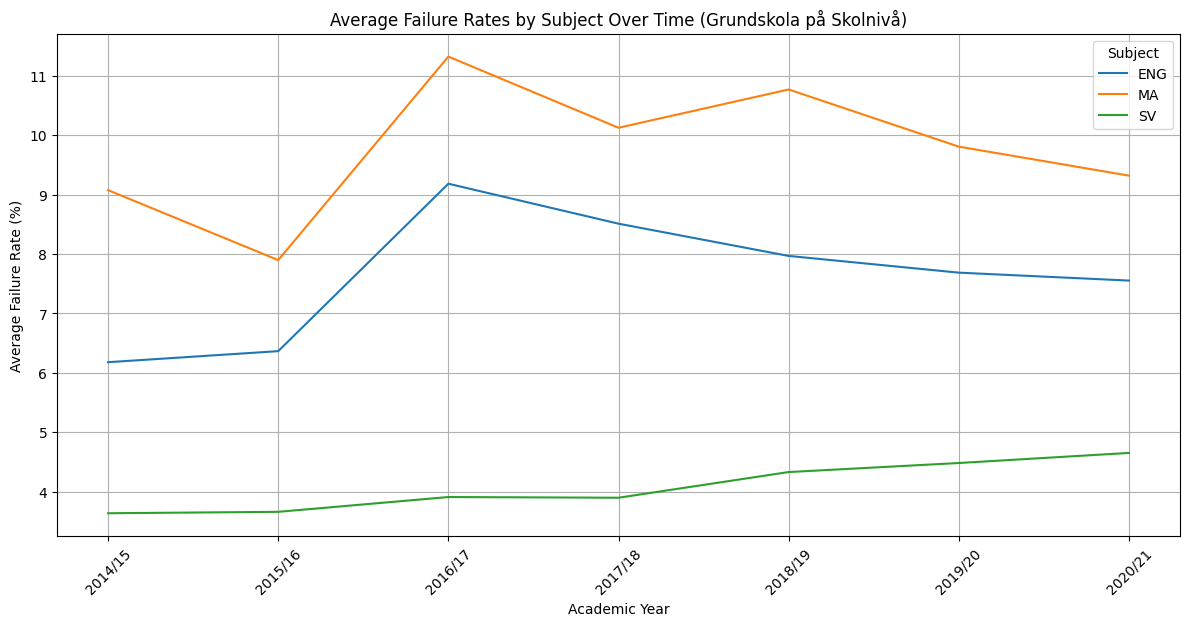

In [15]:
# Step 8 - Time Trends 

# Filter for gymnasieskola only
grundskola_data_data = school_data[school_data['educational_stage'] == 'grundskola'].copy()

# Step 1: Ensure relevant columns are numeric
failure_columns = ['share_students_F_eng', 'share_students_F_ma', 'share_students_F_sv']
grundskola_data_data[failure_columns] = grundskola_data_data[failure_columns].apply(pd.to_numeric, errors='coerce')

# Step 2: Group by academic year and calculate mean failure rates
avg_failure_rates = grundskola_data_data.groupby('academic_year')[failure_columns].mean().reset_index()

# Step 3: Plot the trends
plt.figure(figsize=(12, 6))
for subject in failure_columns:
    plt.plot(avg_failure_rates['academic_year'], avg_failure_rates[subject], label=subject.replace('share_students_F_', '').upper())

plt.title('Average Failure Rates by Subject Over Time (Grundskola på Skolnivå)')
plt.xlabel('Academic Year')
plt.ylabel('Average Failure Rate (%)')
plt.legend(title='Subject')
plt.grid(True)
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()

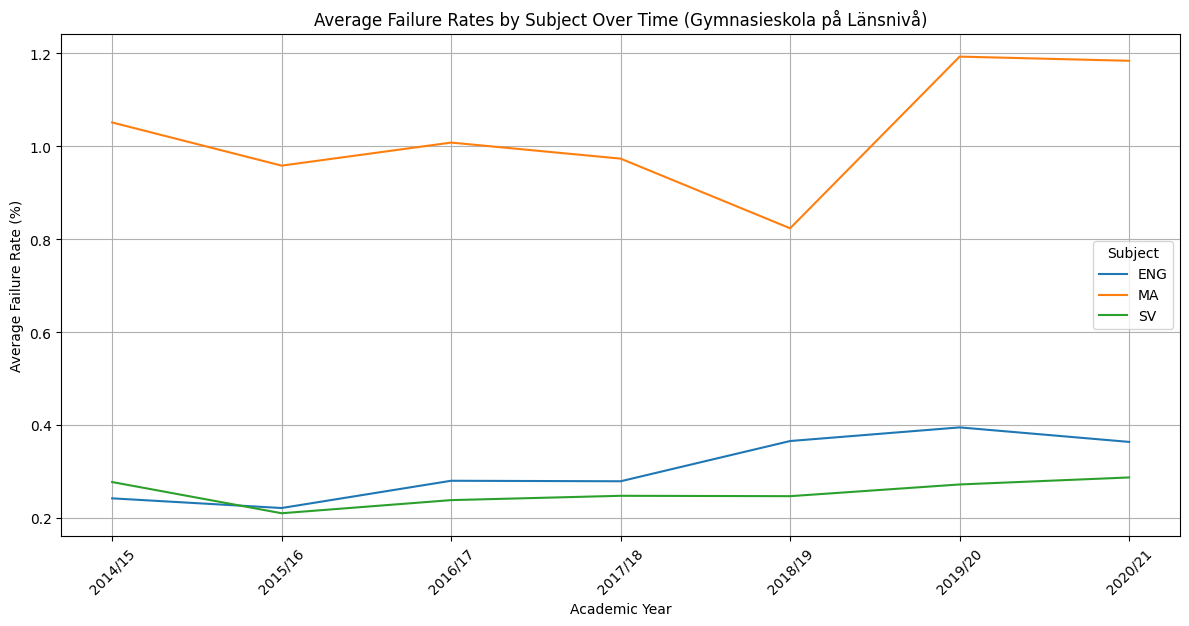

In [16]:
# Step 8 - Time Trends 

# Filter for gymnasieskola only
gymnasieskola_data = school_data[school_data['educational_stage'] == 'gymnasieskola'].copy()

# Step 1: Ensure relevant columns are numeric
failure_columns = ['share_students_F_eng', 'share_students_F_ma', 'share_students_F_sv']
gymnasieskola_data[failure_columns] = gymnasieskola_data[failure_columns].apply(pd.to_numeric, errors='coerce')

# Step 2: Group by academic year and calculate mean failure rates
avg_failure_rates = gymnasieskola_data.groupby('academic_year')[failure_columns].mean().reset_index()

# Step 3: Plot the trends
plt.figure(figsize=(12, 6))
for subject in failure_columns:
    plt.plot(avg_failure_rates['academic_year'], avg_failure_rates[subject], label=subject.replace('share_students_F_', '').upper())

plt.title('Average Failure Rates by Subject Over Time (Gymnasieskola på Länsnivå)')
plt.xlabel('Academic Year')
plt.ylabel('Average Failure Rate (%)')
plt.legend(title='Subject')
plt.grid(True)
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()